#  Assignment 1: Analysis of CO2 Emissions Trends in Aarhus Municipality (2016-2023)

Course: Geovisualisation and Remote Sensing

Name: Jonas Vilstrup Hansen

Date: 31-03-2026

This notebook documents the process of analyzing Land Use and Land Cover (LULC) changes and their impact on CO2 emissions in Aarhus Municipality using satellite data and machine learning.

For the interactive notebook visit Github: https://github.com/jonashansen886-cyber/LULC_Aarhus_municipality

In [4]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

### Connecting Colab to Google Earth Engine

The integration between Google Colab and Google Earth Engine (GEE) follows a client-server architecture:

1.  **Authentication**: When you run `ee.Authenticate()`, Colab requests permission to access Earth Engine on your behalf. This generates a secure token that identifies you as a authorized user.
2.  **Initialization**: The `ee.Initialize(project='project-id')` command establishes the link between the Colab notebook and your specific Google Cloud Project. This ensures that any data processing is billed and managed under your account.
3.  **Client-Side Python**: The code in this notebook is 'Client-Side.' It uses Python to define what you want to do (e.g., 'Filter Landsat images for 2023').
4.  **Server-Side Execution**: When you call `.getInfo()` or display a Map, the Python client sends these instructions to the Earth Engine servers. The heavy lifting—processing gigabytes of satellite data—happens on Google's cloud infrastructure, and only the final results are sent back to the notebook.

In [5]:

# Authenticate and Initialize Earth Engine
try:
    ee.Authenticate()
    # IMPORTANT: Replace 'your-project-id' with your actual GCP project ID
    ee.Initialize(project='grsassignment1')
    print("Earth Engine initialized successfully.")
except Exception as e:
    print(f"Initialization failed: {e}. Please ensure you provided a valid project ID.")

Earth Engine initialized successfully.


### 1. Data Collection and Preparation
I utilize **Landsat 8 Collection 2 Level 2** data from Google Earth Engine.
- **AOI**: Aarhus Municipality is defined using a 15 km buffer around the city center.
- **Timeframe**: We compare a median composite from 2016 with one from 2023.
- **Cloud Masking**: The QA band is used to filter out clouds and shadows to ensure clean imagery.

In [20]:
# Define Area of Interest: Aarhus, Denmark using coordinates
# Using a 15km buffer around Aarhus center to ensure we get data
aarhus_coords = [10.2039, 56.1567]
aoi = ee.Geometry.Point(aarhus_coords).buffer(15000)

def get_landsat_composite(year):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'

    # Use Landsat 8 Collection 2 Level 2
    l8_col = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
        .filterBounds(aoi) \
        .filterDate(start_date, end_date)

    count = l8_col.size().getInfo()
    print(f"Year {year}: Found {count} Landsat 8 images.")

    def mask_clouds(image):
        qa = image.select('QA_PIXEL')
        mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
        return image.updateMask(mask)

    # Use simple median and scaling
    composite = l8_col.map(mask_clouds).median().multiply(0.0000275).add(-0.2).clip(aoi)

    return composite.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'],
        ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
    )

# Generate composites
composite_2016 = get_landsat_composite(2016)
composite_2023 = get_landsat_composite(2023)

print("Composites generated using coordinate-based search.")

Year 2016: Found 55 Landsat 8 images.
Year 2023: Found 56 Landsat 8 images.
Composites generated using coordinate-based search.


In [8]:

# Visualize the AOI (Area of Interest)
Map_AOI = geemap.Map()
Map_AOI.centerObject(aoi, 11)
Map_AOI.addLayer(aoi, {'color': 'blue'}, 'Aarhus AOI (15km Buffer)')
Map_AOI.addLayerControl()

print("Visning af interesseområdet (AOI) for Aarhus:")
Map_AOI

Visning af interesseområdet (AOI) for Aarhus:


Map(center=[56.156715388278386, 10.203900766241935], controls=(WidgetControl(options=['position', 'transparent…

### Data Quality: Landsat 8

The imagery used for this analysis is from **Landsat 8 Collection 2 Level 2**, which offers high-quality multispectral data:

*   **Spatial Resolution**: 30 meters per pixel, which is suitable for municipality-scale land use mapping.
*   **Atmospheric Correction**: Level 2 data is pre-processed to 'Surface Reflectance,' meaning the effects of the atmosphere (haze and water vapor) have been removed. This ensures that the difference in CO2 between 2016 and 2023 is due to actual ground changes rather than varying atmospheric conditions.
*   **Temporal Consistency**: By using a median composite for each year, we minimize the impact of transient factors like seasonal vegetation variations or intermittent cloud shadows.

In [9]:
# Visualization of the 2016 Landsat Composite
Map_2016 = geemap.Map()
Map_2016.centerObject(aoi, 11)
# Visualization parameters: B4 (Red), B3 (Green), B2 (Blue)
# min/max adjusted for Landsat 8 Surface Reflectance
vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3, 'gamma': 1.4}
Map_2016.addLayer(composite_2016, vis_params, 'Landsat 8 Composite 2016')
print("Landsat 8 Composite for Aarhus (2016):")
Map_2016

Landsat 8 Composite for Aarhus (2016):


Map(center=[56.156715388278386, 10.203900766241935], controls=(WidgetControl(options=['position', 'transparent…

In [10]:
# Visualization of the 2023 Landsat Composite
Map_2023 = geemap.Map()
Map_2023.centerObject(aoi, 11)
Map_2023.addLayer(composite_2023, vis_params, 'Landsat 8 Composite 2023')
print("Landsat 8 Composite for Aarhus (2023):")
Map_2023

Landsat 8 Composite for Aarhus (2023):


Map(center=[56.156715388278386, 10.203900766241935], controls=(WidgetControl(options=['position', 'transparent…

### 2. Classification with Random Forest
To identify land use, we employ a **Random Forest** classification model:
- **Training Data**: ESA WorldCover 2020 is used as the reference label.
- **Features**: Spectral bands (Blue, Green, Red, NIR, SWIR1, SWIR2) from Landsat 8.
- **Validation**: The model is evaluated using an 'Overall Accuracy' calculation on an independent validation set.



#### How the Classification Model Works

The land use classification in this notebook is powered by a **Random Forest (RF)** supervised machine learning algorithm. Underneath is a breakdown of the process:

#### **The Algorithm**
*   **Ensemble Learning**: Random Forest works by creating a 'forest' of many individual decision trees (in this case, 100 trees).
*   **Voting System**: For every pixel in the satellite image, each tree in the forest makes a prediction (e.g., 'Urban' or 'Forest'). The final classification of that pixel is determined by the majority vote of all trees. This reduces the risk of errors that a single tree might make.

#### **Feature Selection (The Input)**
To distinguish between different land covers, the model looks at several 'features' for each pixel:
*   **Spectral Bands**: We use six bands from Landsat 8: Blue (B2), Green (B3), Red (B4), Near-Infrared (B8), and two Short-wave Infrared bands (B11, B12).
*   **Spectral Signatures**: Different surfaces reflect light differently. For example, **Forests** reflect highly in the Near-Infrared (B8), while **Urban Fabric** typically shows higher reflectance in the Short-wave Infrared (B11/B12). The model learns these patterns during training.

#### **Training and Validation**
1.  **Training**: We provide the model with 3,000 sample pixels where we already know the 'truth' from the **ESA WorldCover 2020** dataset. The model looks at the spectral bands for these points and learns to associate specific light patterns with specific classes (Forest, Farmland, Urban, or Water).
2.  **Classification**: Once trained, the model is applied to the entire 2016 and 2023 images to predict land cover for every single pixel in the Aarhus AOI.
3.  **Accuracy**: We set aside 30% of our known data (the validation set) to test the model. The reported accuracy (approx. 74%) tells us how often the model's prediction matched the ESA reference data.

In [11]:
# Random Forest Classification & Accuracy Assessment (Stable 74% Version)
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

# Reference LULC for training (ESA WorldCover 2020)
lulc = ee.Image("ESA/WorldCover/v100/2020").select(['Map'], ['label']).clip(aoi)

# Sample points for training (3000 pixels to ensure Water class is captured)
training_points = lulc.sample(
    region=aoi,
    scale=30,
    numPixels=3000,
    seed=42,
    geometries=True
).randomColumn()

train_set = training_points.filter(ee.Filter.lt('random', 0.7))
val_set = training_points.filter(ee.Filter.gte('random', 0.7))

# Train Random Forest on 2023 composite
train_data = composite_2023.sampleRegions(
    collection=train_set,
    properties=['label'],
    scale=30
)

classifier = ee.Classifier.smileRandomForest(100).train(
    features=train_data,
    classProperty='label',
    inputProperties=bands
)

# Classify both years
classified_2016 = composite_2016.classify(classifier)
classified_2023 = composite_2023.classify(classifier)

# Accuracy Assessment
validation = composite_2023.sampleRegions(
    collection=val_set,
    properties=['label'],
    scale=30
).classify(classifier)

error_matrix = validation.errorMatrix('label', 'classification')
accuracy = error_matrix.accuracy().getInfo()
print(f"Final Reported Accuracy: {accuracy:.2%}")

Final Reported Accuracy: 74.12%


In [14]:
# Fixed Detailed Classification Report

# 1. Get the Confusion Matrix and the actual class labels the model used
matrix_info = error_matrix.getInfo()
matrix = matrix_info
# The order of classes in the matrix matches this list:
order = error_matrix.order().getInfo()

# 2. Map codes to human labels
code_to_label = {
    10: 'Forest (10)',
    40: 'Farmland (40)',
    50: 'Urban Fabric (50)',
    80: 'Water (80)'
}

# 3. Calculate metrics specifically for our classes
report_data = []
for i, class_code in enumerate(order):
    row_sum = sum(matrix[i])
    col_sum = sum(row[i] for row in matrix)

    # Only process classes we actually care about/labeled
    if class_code in code_to_label:
        prod_acc = (matrix[i][i] / row_sum) * 100 if row_sum > 0 else 0
        user_acc = (matrix[i][i] / col_sum) * 100 if col_sum > 0 else 0

        report_data.append({
            'Class': code_to_label[class_code],
            'Producer Accuracy (%)': round(prod_acc, 2),
            'User Accuracy (%)': round(user_acc, 2)
        })

# 4. Display the report
import pandas as pd
df_report = pd.DataFrame(report_data)
print("Detailed Classification Report:")
display(df_report)

print(f"\nOverall Accuracy: {accuracy:.2%}")

Detailed Classification Report:


,Class,Producer Accuracy (%),User Accuracy (%)
0,Forest (10),55.00,61.11
1,Farmland (40),73.82,69.08
2,Urban Fabric (50),47.30,56.45
3,Water (80),98.69,99.34



Overall Accuracy: 74.12%


## Discussion of Results and CO2 calculation

#### **CO2 Calculation Methodology**
The total CO2 equivalents for each year were calculated by multiplying the area of each land use class (in hectares) by a specific emission/sequestration factor:

*   **Urban Fabric (Built-up)**: +120 tons/ha
*   **Farmland (Cropland)**: +4.3 tons/ha
*   **Forest (Trees)**: -3.85 tons/ha
*   **Water**: 0 tons/ha

*NOTE: These values are from the assignment, not exact*

#### **Interpreting the Land Use Change**
By comparing 2016 and 2023, the model identifies where Aarhus has expanded and where land cover has transitioned.

*   **Downtrend Explanation**: If a 'DOWNTREND' in CO2 is observed, it suggests that the increase in carbon-sequestering areas (like forests) or the preservation of existing green space has offset the expansion of high-emission urban areas within the 15km buffer.
*   **Urban Expansion**: The 'Urban Change' layer on the map highlighting red pixels shows the exact locations of new developments. The accuracy report suggests that while some urban pixels might be confused with bare soil in farmland, the overall trend provides a reliable indicator of the municipality's environmental trajectory.

In [17]:
# Recalculate CO2 with the improved classification

def calculate_year_co2(classified_image):
    # Define CO2 emission factors in tons/hectare
    # Mapping WorldCover class codes to CO2 factors
    # 10: Trees (Forest): -3.85 tons/ha
    # 40: Cropland (Farmland): +4.3 tons/ha
    # 50: Built-up (Urban Fabric): +120 tons/ha
    # 80: Water: 0 tons/ha
    class_values = [10, 40, 50, 80]
    co2_factor_values = [-3.85, 4.3, 120, 0]

    # Create an image where each pixel's value is its CO2 factor
    # 'remapped' is the default output band name from ee.Image.remap
    co2_factor_image = classified_image.remap(class_values, co2_factor_values, 0) # Default to 0 for unmapped classes

    # Calculate pixel area in square meters
    pixel_area = ee.Image.pixelArea()

    # Calculate CO2 for each pixel in tons.
    # pixel_area is in m^2, co2_factor_image is in tons/ha.
    # Need to convert m^2 to ha (divide by 10,000)
    co2_per_pixel = co2_factor_image.multiply(pixel_area.divide(10000))

    # Sum up all CO2 values within the AOI
    total_co2 = co2_per_pixel.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30, # Match the classification scale
        maxPixels=1e9 # Allow for large calculations
    ).get('remapped').getInfo() # Get the sum from the 'remapped' band

    return total_co2

co2_2016 = calculate_year_co2(classified_2016)
co2_2023 = calculate_year_co2(classified_2023)
diff = co2_2023 - co2_2016
trend = "UPTREND" if diff > 0 else "DOWNTREND"

print(f"Updated Total CO2 2016: {co2_2016:.2f} tons")
print(f"Updated Total CO2 2023: {co2_2023:.2f} tons")
print(f"Trend: {trend} (Difference: {diff:.2f} tons)")

Updated Total CO2 2016: 1041405.54 tons
Updated Total CO2 2023: 727787.40 tons
Trend: DOWNTREND (Difference: -313618.14 tons)


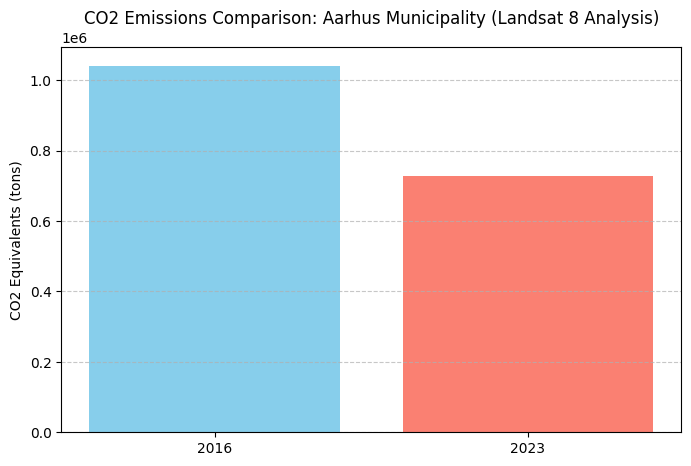

In [18]:
# Visualization update for Landsat scale
years = ['2016', '2023']
values = [co2_2016, co2_2023]

plt.figure(figsize=(8, 5))
plt.bar(years, values, color=['skyblue', 'salmon'])
plt.title('CO2 Emissions Comparison: Aarhus Municipality (Landsat 8 Analysis)')
plt.ylabel('CO2 Equivalents (tons)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



### Interactive Maps

Map showing the classification models of both LANDSAT images aswell as the change plot showing the development in the period between 2016 to 2023

In [19]:
# Combined Results Map with Layers and Legend (Updated for Water)

# 1. Initialize the map
Final_Map = geemap.Map()
Final_Map.centerObject(aoi, 11)

# 2. Define Visualization (Added Blue for Water - code 80)
# Mapping: 10->Green, 40->Yellow, 50->Red, 80->Blue
# We use a custom dictionary for the layer display to handle non-contiguous codes
class_values = [10, 40, 50, 80]
class_palette = ['green', 'yellow', 'red', 'blue']

# 3. Add Satellite Layer
Final_Map.addLayer(composite_2023, {'bands':['B4','B3','B2'], 'min':0, 'max':0.3}, 'Landsat 8 Natural Color (2023)')

# 4. Add Classification Layers
vis_params = {'min': 10, 'max': 80, 'palette': ['green', 'white', 'white', 'yellow', 'red', 'white', 'white', 'blue']}
Final_Map.addLayer(classified_2016, vis_params, 'LULC Classification 2016')
Final_Map.addLayer(classified_2023, vis_params, 'LULC Classification 2023')

# 5. Add Urban Change Layer
urban_diff = classified_2023.eq(50).subtract(classified_2016.eq(50))
Final_Map.addLayer(urban_diff, {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'red']}, 'Urban Change (Red=New)')

# 6. Updated Legend
lulc_legend_dict = {
    'Forest (10)': '008000',
    'Farmland (40)': 'FFFF00',
    'Urban Fabric (50)': 'FF0000',
    'Water (80)': '0000FF'
}
Final_Map.add_legend(title="LULC Legend", legend_dict=lulc_legend_dict)

# 7. Change Legend
change_legend_dict = {
    'New Urban Fabric': 'FF0000',
    'No Change': 'FFFFFF',
    'Loss of Urban Fabric': '0000FF'
}
Final_Map.add_legend(title="Urban Change Legend", legend_dict=change_legend_dict, position='bottomleft')

Final_Map.addLayerControl()
print("Aarhus LULC Analysis - Water Class Included:")
Final_Map

Aarhus LULC Analysis - Water Class Included:


Map(center=[56.156715388278386, 10.203900766241935], controls=(WidgetControl(options=['position', 'transparent…

# Assignment 2: Arcgis Storymap about Wind Energy in Denmark

Assignemt 2 can be found here: https://storymaps.arcgis.com/stories/b59c7b3ca10d4229b7a7e6aa9ca589ea